# IMDb Sentiment Analysis: Exploratory Data Analysis (EDA)
**Deep Learning Midterm Project**  
This notebook covers all EDA requirements from Section 2.2 of the project spec:
1. Class distribution (bar chart)
2. Sequence length statistics (min, max, mean, 90th percentile)
3. Vocabulary frequency (top-30 token bar chart)
4. Representative samples (3–5 positive and negative reviews)

## 0. Set-up and Import

In [2]:
# Install if needed
! pip install datasets

import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('All imports successful.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 4.2 MB/s  0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/27.6 MB 5.6 MB/s eta 0:00:05
   --- ------------------------------------ 2.6/27.6 MB 6.0 MB/s eta 0:00:05
   ----- ---------------------------------- 3.9/27.6 MB 6.0 MB/s eta 0:00:04
   ------ --------------------------------- 4.7/27.6 MB 5.6 MB/s eta 0:00:05
   -------- ------------------------------- 5.8/27.6 MB 5.4 MB/s eta 0:00:05
   --------- ------------------------------ 6.3/27.6 MB 5.2 MB/s eta 0:00:05
   ----------- ---------------------------- 7.9/27.6 MB 5.3 MB/s eta 0:00:04
   ------------ --------------------------- 8.4/27.6 MB 5.0 MB/s eta 0:00:04
   -------------- ------------------------- 9.7/27.6 MB 5.1 MB/s eta 0:00:04
   --------------- ------------------------ 10.7/27.6 MB 5.1 MB/s eta 0:00:04
   --------

d:\JupyterEnvs\my_new_kernel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


## 1. Load Dataset

In [3]:
dataset = load_dataset('imdb')

train_data = dataset['train']  # 25,000 samples
test_data  = dataset['test']   # 25,000 samples

# Quick sanity check
print(dataset)
print(f'\nTrain size: {len(train_data):,} samples')
print(f'Test  size: {len(test_data):,} samples')
print(f'Label distribution: {sum(train_data["label"])}/{len(train_data["label"])} positive')
print(f'\nSample entry:\n  label={train_data[0]["label"]}  text={train_data[0]["text"][:120]}...')

d:\JupyterEnvs\my_new_kernel_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ko Paing Hein\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. Fo

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size: 25,000 samples
Test  size: 25,000 samples
Label distribution: 12500/25000 positive

Sample entry:
  label=0  text=I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first rel...


## 2. Text Cleaning Helper
IMDb reviews contain HTML tags (e.g. `<br />`). We strip them before any analysis.

In [4]:
def clean_text(text: str) -> str:
    """Remove HTML tags, lowercase, strip extra whitespace."""
    text = re.sub(r'<[^>]+>', ' ', text)   # strip HTML
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to training set
train_texts  = [clean_text(ex['text']) for ex in train_data]
train_labels = [ex['label'] for ex in train_data]

test_texts   = [clean_text(ex['text']) for ex in test_data]
test_labels  = [ex['label'] for ex in test_data]

# Verify cleaning
print('Before:', train_data[0]['text'][:150])
print('After: ', train_texts[0][:150])

Before: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th
After:  i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard th


## 3. EDA Req-1: Class Distribution

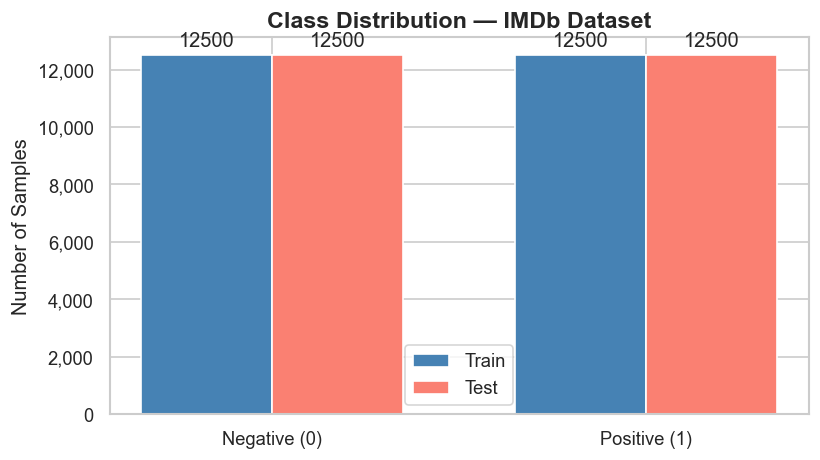


Train — Negative: 12,500  Positive: 12,500
Test  — Negative: 12,500   Positive: 12,500

Conclusion: The dataset is perfectly balanced (50/50 split for both splits).
No class-weighting or oversampling is needed.


In [5]:
label_names  = ['Negative (0)', 'Positive (1)']
train_counts = [train_labels.count(0), train_labels.count(1)]
test_counts  = [test_labels.count(0),  test_labels.count(1)]

x = np.arange(len(label_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_train = ax.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
bars_test  = ax.bar(x + width/2, test_counts,  width, label='Test',  color='salmon')

ax.set_title('Class Distribution — IMDb Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_xticks(x)
ax.set_xticklabels(label_names)
ax.legend()
ax.bar_label(bars_train, padding=3)
ax.bar_label(bars_test,  padding=3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('eda_class_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nTrain — Negative: {train_counts[0]:,}  Positive: {train_counts[1]:,}')
print(f'Test  — Negative: {test_counts[0]:,}   Positive: {test_counts[1]:,}')
print('\nConclusion: The dataset is perfectly balanced (50/50 split for both splits).')
print('No class-weighting or oversampling is needed.')

## 4. EDA Req-2: Sequence Length Statistics

=== Train Sequence Length Statistics (tokens) ===
       min: 10.0
       max: 2459.0
      mean: 231.5
    median: 173.0
       p90: 454.0
       p95: 592.0
       p99: 907.0


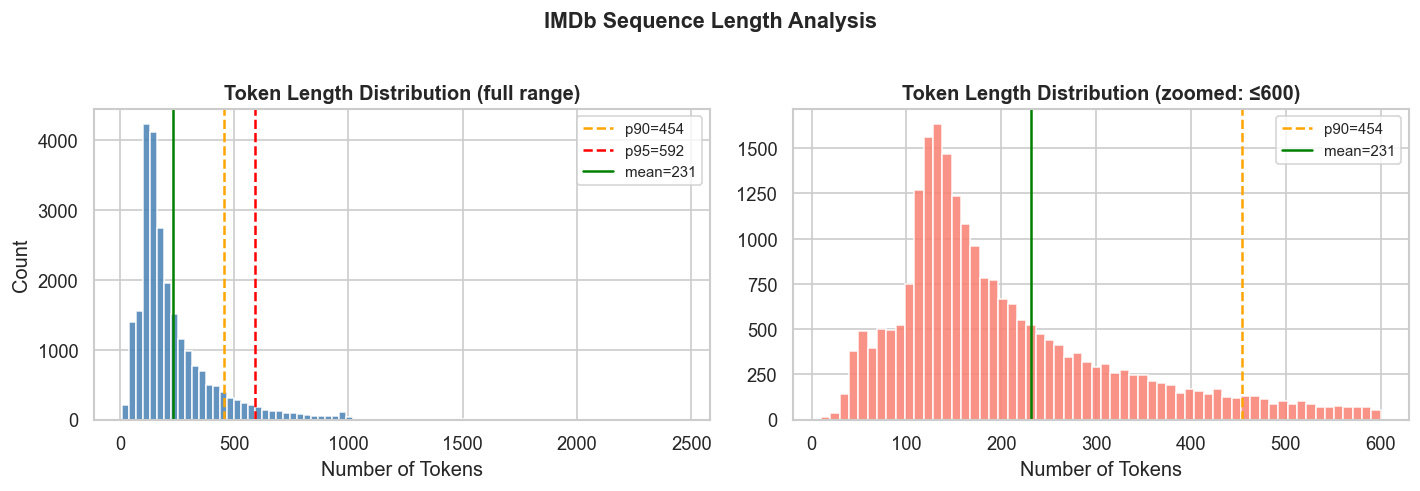


Recommendation: Set max_len = 454 (90th percentile).
This covers ~90% of reviews without excessive padding.
The remaining ~10% will be truncated (typically very long, repetitive reviews).


In [6]:
# Tokenise by whitespace (same strategy we'll use in the pipeline)
train_lengths = [len(t.split()) for t in train_texts]
test_lengths  = [len(t.split()) for t in test_texts]

stats = {
    'min':    np.min(train_lengths),
    'max':    np.max(train_lengths),
    'mean':   np.mean(train_lengths),
    'median': np.median(train_lengths),
    'p90':    np.percentile(train_lengths, 90),
    'p95':    np.percentile(train_lengths, 95),
    'p99':    np.percentile(train_lengths, 99),
}

print('=== Train Sequence Length Statistics (tokens) ===')
for k, v in stats.items():
    print(f'  {k:>8}: {v:.1f}')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
axes[0].hist(train_lengths, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
for pct, val, col in [(90, stats['p90'], 'orange'), (95, stats['p95'], 'red')]:
    axes[0].axvline(val, color=col, linestyle='--', linewidth=1.5, label=f'p{pct}={val:.0f}')
axes[0].axvline(stats['mean'], color='green', linestyle='-', linewidth=1.5, label=f'mean={stats["mean"]:.0f}')
axes[0].set_title('Token Length Distribution (full range)', fontweight='bold')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Zoomed (0–600 tokens covers ~95%+ of data)
axes[1].hist([l for l in train_lengths if l <= 600], bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].axvline(stats['p90'], color='orange', linestyle='--', linewidth=1.5, label=f'p90={stats["p90"]:.0f}')
axes[1].axvline(stats['mean'], color='green', linestyle='-', linewidth=1.5, label=f'mean={stats["mean"]:.0f}')
axes[1].set_title('Token Length Distribution (zoomed: ≤600)', fontweight='bold')
axes[1].set_xlabel('Number of Tokens')
axes[1].legend(fontsize=9)

plt.suptitle('IMDb Sequence Length Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_sequence_lengths.png', bbox_inches='tight')
plt.show()

print(f'\nRecommendation: Set max_len = {int(stats["p90"])} (90th percentile).')
print(f'This covers ~90% of reviews without excessive padding.')
print(f'The remaining ~10% will be truncated (typically very long, repetitive reviews).')

## 5. EDA Req-3: Voculary Frequency

Total tokens (raw):      5,787,066
Vocabulary size (raw):   236,042
After stop-word removal: 235,890 unique tokens


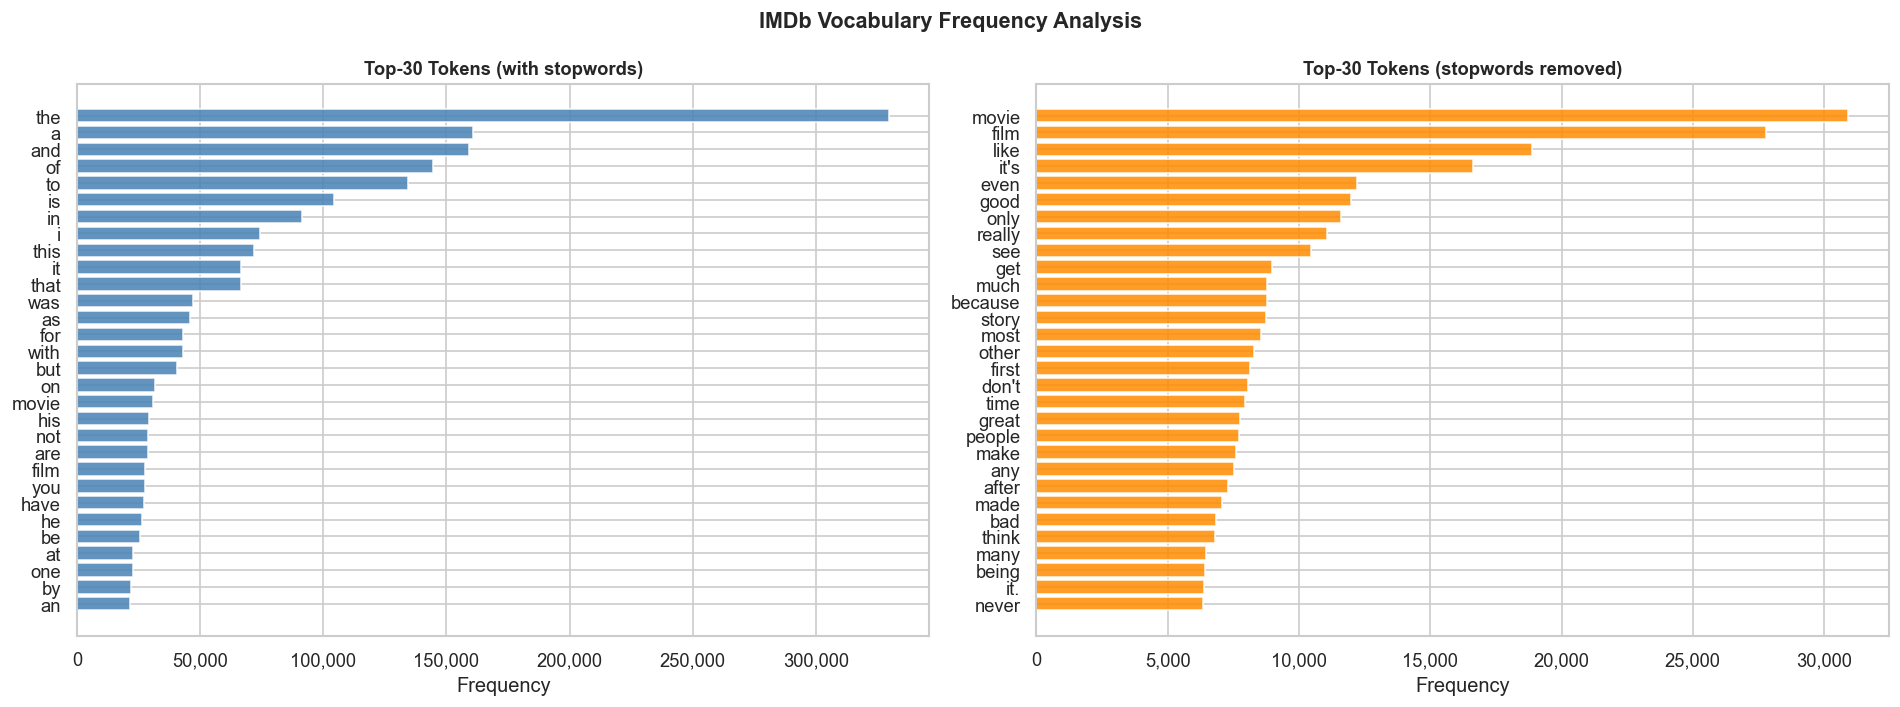


Conclusion: Without removal, top tokens are function words with no sentiment value.
After removal, sentiment-bearing words (film, good, great, bad, story) dominate — 
confirming that stop-word removal is beneficial for the MLP BoW baseline.


In [7]:
# --- Without stop-word removal ---
all_tokens_raw = [tok for text in train_texts for tok in text.split()]
freq_raw = Counter(all_tokens_raw)
top30_raw = freq_raw.most_common(30)

# --- With stop-word removal (manual lightweight list) ---
STOPWORDS = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','it','this','that','i','he','she','they','we','you','be',
    'are','were','has','have','had','as','by','from','not','his','her',
    'their','its','my','your','our','so','if','do','did','will','would',
    'could','should','there','than','then','just','more','also','about',
    'up','out','one','what','which','who','all','no','been','very','into',
    'when','me','him','them','how','some','can','s','t','re','ll','ve','m'
])

all_tokens_filtered = [t for t in all_tokens_raw if t not in STOPWORDS and len(t) > 1]
freq_filtered = Counter(all_tokens_filtered)
top30_filtered = freq_filtered.most_common(30)

print(f'Total tokens (raw):      {len(all_tokens_raw):,}')
print(f'Vocabulary size (raw):   {len(freq_raw):,}')
print(f'After stop-word removal: {len(freq_filtered):,} unique tokens')

# Plot both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, top30, title, color in [
    (axes[0], top30_raw,      'Top-30 Tokens (with stopwords)',    'steelblue'),
    (axes[1], top30_filtered, 'Top-30 Tokens (stopwords removed)', 'darkorange'),
]:
    words, counts = zip(*top30)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.suptitle('IMDb Vocabulary Frequency Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_vocab_frequency.png', bbox_inches='tight')
plt.show()

print('\nConclusion: Without removal, top tokens are function words with no sentiment value.')
print('After removal, sentiment-bearing words (film, good, great, bad, story) dominate — ')
print('confirming that stop-word removal is beneficial for the MLP BoW baseline.')

## 6. EDA Req-4: Representative samples

In [8]:
import random
random.seed(42)

pos_indices = [i for i, l in enumerate(train_labels) if l == 1]
neg_indices = [i for i, l in enumerate(train_labels) if l == 0]

sample_pos = random.sample(pos_indices, 3)
sample_neg = random.sample(neg_indices, 3)

print('=' * 70)
print('POSITIVE REVIEWS (label = 1)')
print('=' * 70)
for rank, idx in enumerate(sample_pos, 1):
    preview = train_texts[idx][:300].replace('\n', ' ')
    tokens  = len(train_texts[idx].split())
    print(f'\n[Sample P{rank}] — {tokens} tokens')
    print(f'  "{preview}..."')

print()
print('=' * 70)
print('NEGATIVE REVIEWS (label = 0)')
print('=' * 70)
for rank, idx in enumerate(sample_neg, 1):
    preview = train_texts[idx][:300].replace('\n', ' ')
    tokens  = len(train_texts[idx].split())
    print(f'\n[Sample N{rank}] — {tokens} tokens')
    print(f'  "{preview}..."')

POSITIVE REVIEWS (label = 1)

[Sample P1] — 287 tokens
  "having read some of the other comments here i was expecting something truly awful but was pleasantly surprised. reality check: the original series wasn't that good. i think some people remember it with more affection than it deserved but apart from the car chases and daisy duke's legs the scripts we..."

[Sample P2] — 262 tokens
  "arthur is middle aged rich 'kid' who drinks like a fish. arthur does what he feels like and says whatever comes into his mind. he likes to boast about his riches and knows that he is a spoiled brat. he spends money on people he don't know and finds everything funny. arthur must marry a high class gi..."

[Sample P3] — 129 tokens
  "'the luzhin defence' is a movie worthy of anyone's time. it is a brooding, intense film, and kept my attention the entire time. john turturro is absolutely stunning in his portrayal of a tender, eccentric chess grandmaster, and emily watson is spell-binding as the gentle bu

In [9]:
max_len_choice = int(np.percentile(train_lengths, 90))
vocab_size_estimate = len([w for w, c in freq_filtered.items() if c >= 5])  # min_freq=5

print('╔══════════════════════════════════════════════════════════╗')
print('║           EDA SUMMARY & PIPELINE DECISIONS              ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Dataset        : IMDb (50,000 total, 25k train/test)   ║')
print(f'║  Class balance  : Perfectly balanced (50% pos / 50% neg)║')
print(f'║  Avg length     : {stats["mean"]:.0f} tokens                         ║')
print(f'║  90th pct length: {stats["p90"]:.0f} tokens                         ║')
print(f'║  → max_len      : {max_len_choice} (covers ~90% without truncation) ║')
print(f'║  → vocab_size   : ~{vocab_size_estimate:,} (min_freq ≥ 5)              ║')
print(f'║  Stop-words     : Remove (no sentiment signal)          ║')
print(f'║  HTML cleaning  : Required (<br />, <i>, etc.)          ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║           EDA SUMMARY & PIPELINE DECISIONS              ║
╠══════════════════════════════════════════════════════════╣
║  Dataset        : IMDb (50,000 total, 25k train/test)   ║
║  Class balance  : Perfectly balanced (50% pos / 50% neg)║
║  Avg length     : 231 tokens                         ║
║  90th pct length: 454 tokens                         ║
║  → max_len      : 454 (covers ~90% without truncation) ║
║  → vocab_size   : ~44,762 (min_freq ≥ 5)              ║
║  Stop-words     : Remove (no sentiment signal)          ║
║  HTML cleaning  : Required (<br />, <i>, etc.)          ║
╚══════════════════════════════════════════════════════════╝
